In [50]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
from torch import autograd as Grad

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.tri as mtri
import matplotlib
from IPython.display import display, clear_output


import ipywidgets as widgets
from IPython.display import display
import trimesh

import random
import math

import time
import os
import json

import copy
import subprocess
import shutil

import open3d as o3d
print(o3d.__path__)
print('Using open3d version',o3d.__version__)
# Suppress Open3D warnings
o3d.utility.set_verbosity_level(o3d.utility.VerbosityLevel.Error)


from visuals import *

from bns_utils import *
from mesh_processing import *

import differential
import importlib
importlib.reload(differential)
from differential import *

two_pi = 2*torch.pi
eps = 1.0e-6

diffmod = DifferentialModule()

# Set the device that we will create the BPS on

device = 'mps'

print(f"Using device: {device}")

coeffs_path = None

['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: mps


In [51]:
#Read in a config file that specifies the settings for a BPS (e.g. the sdf, the coarse mesh file, the blend function, the polynomial degree)
#e.g. sphere100, torus100, camera200, spike




#config_filepath = "configs/surfaces/bob500-inv-exp.json"
#config_filepath = "configs/surfaces/bob500-trig.json"

config_filepath = "configs/surfaces/fertility500-djuren.json"
#config_filepath = "configs/surfaces/fertility500-inv-exp.json"



#config_filepath = "configs/surfaces/fertility300_no_posenc.json"

#config_filepath = "configs/surfaces/bob400.json"
#config_filepath = "configs/surfaces/wobbly_torus500-diffmesh.json"
#config_filepath = "configs/surfaces/twisted_torus200.json"
#config_filepath = "configs/surfaces/twisted_torus500.json"
#config_filepath = "configs/surfaces/igea500-cubic.json"
#config_filepath = "configs/surfaces/rippley400.json"
#config_filepath = "configs/surfaces/lion-reference200.json"

#config_filepath = "configs/surfaces/mobius220.json"
#config_filepath = "configs/surfaces/bob500.json"
#config_filepath = "configs/surfaces/sphere100.json"
#config_filepath = "configs/surfaces/urchin210.json"

#config_filepath = "configs/surfaces/arm500-inv-exp.json"



config_filepath = "configs/surfaces/fandisk500-inv-exp.json"
#coeffs_path = 'models/surfaces/fandisk500.pth'

config_filepath = "configs/surfaces/dice500-inv-exp.json"
#coeffs_path = 'models/surfaces/dice500.pth'

config_filepath = "configs/surfaces/dice520-inv-exp.json"
#coeffs_path = 'models/surfaces/dice520.pth'


config_filepath = "configs/surfaces/oloid100-inv-exp.json"
#coeffs_path = 'models/surfaces/oloid100.pth'


config_filepath = "configs/surfaces/arm500-inv-exp.json"
#coeffs_path = 'models/surfaces/arm500.pth'

#config_filepath = "configs/surfaces/double_torusMC436-inv-exp.json"
#coeffs_path = "models/surfaces/double_torusMC436.pth"

config_filepath = "configs/surfaces/double_torus500-inv-exp.json"
coeffs_path = "models/surfaces/double_torus500.pth"

#config_filepath = "configs/surfaces/arm500-inv-exp.json"


#config_filepath = "configs/surfaces/gear500-inv-exp.json"
#coeffs_path = 'models/surfaces/gear500.pth'


visualise = True


with open(config_filepath, "r") as f:
    config_dict = json.load(f)
    namestring = stringify_config(config_dict)
    print('Namestring will be ', namestring)
    
    shape_name = config_dict['shape-name']
    surface_config = config_dict['surface-config']
    training_config = config_dict['training-config']



# Which DeepSDF architecture the checkpoint was trained with. If the
# config specifies "model_variant" directly (see
# implicit_reps.DEEPSDF_MODEL_VARIANTS for the options), that's used;
# otherwise it's derived from the older "posenc"/"activation" fields for
# backward compatibility with existing config files.
model_variant = training_config.get('model_variant', None)
posenc = training_config.get('posenc', True)
activation = training_config.get('activation', None)


if 'sdf_weights_path' in training_config.keys():
    DEEPSDF_MODEL = load_deepsdf_model(
        ckpt_path='sdf_weights/surfaces/' + training_config['sdf_weights_path'],
        device=device,
        model_variant=model_variant,
        posenc=posenc,
        activation=activation,
    )
else:
    DEEPSDF_MODEL = None

if 'sdf_transition_width' in training_config.keys():
    transition_width = training_config['sdf_transition_width']
else:
    transition_width=0.0

testing = True          # set False to enable saving
save    = not testing


Namestring will be  double_torus___surf__=pou_inv_exp__=double_torus500__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=100__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F
Loading deepsdf model onto mps (variant='posenc')
DeepSDF Model loaded successfully on device: mps


In [52]:
# --- Sanity check: evaluate the implicit function on the proxy mesh's
# vertices. The proxy is meant to approximate the zero level set of the
# SDF, so these values should be small.
proxy_filepath = 'data/surfaces/' + surface_config['coarse_patches_id'] + '.obj'
proxy_mesh = trimesh.load(proxy_filepath, process=False)

proxy_verts = torch.tensor(proxy_mesh.vertices, dtype=torch.float32, device=device).unsqueeze(0)

with torch.no_grad():
    proxy_sdf_vals = sdf(
        proxy_verts,
        training_config['sdf_id'],
        squared=False,
        model=DEEPSDF_MODEL,
        transition_width=transition_width
    )

print(f"Implicit function value on {proxy_mesh.vertices.shape[0]} proxy vertices ({proxy_filepath}):")
print(f"  mean |sdf| = {proxy_sdf_vals.abs().mean().item():.6f}")
print(f"  max  |sdf| = {proxy_sdf_vals.abs().max().item():.6f}")

Implicit function value on 248 proxy vertices (data/surfaces/double_torus500.obj):
  mean |sdf| = 0.002776
  max  |sdf| = 0.008862


In [53]:

import BPS
importlib.reload(BPS)
from BPS import BPS_fast

# instantiate
bps = BPS_fast( surface_config, device=device)

#bps.load_poly_coeffs('results/bob/best_pou_trig_coeffs.pth')      #good
#bps.load_poly_coeffs('results/bob/best_pou_inv_exp_coeffs.pth')    ## good I think
#bps.load_poly_coeffs('results/bob/best_coeffs.pth')   ##ok I think not sure if trig or inv epx
#bps.load_poly_coeffs('results/fertility/best-coeffs-inv-exp.pth')


#bps.load_poly_coeffs('results/urchin/best_coeffs.pth')
#bps.load_poly_coeffs('results/twisted_torus/pou_inv_exp_coeffs.pth')
#bps.load_poly_coeffs('results/igea/15apr-pou-inv-coeffs.pth')

#bps.load_poly_coeffs('results/fertility/best-coeffs-inv-exp.pth')

#bps.load_poly_coeffs('models/surfaces/arm500.pth')

if not coeffs_path is None:
    bps.load_poly_coeffs(coeffs_path)

Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on mps
HalfEdgeTriangleMesh with 248 points and 1500 half edges.
mean edge length tensor(0.1365, device='mps:0')
Using Local Scales
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
sharp edges obj []
sharp edges o3d []
sharp halfedges: []
Computing rotations.


/Users/romywilliamson/Documents/BNS/BCSv2/BPS.py:1018: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(filename, map_location=self.device)


In [54]:
################# visualise BNS ##########################


if visualise==True:
    
    import visuals
    importlib.reload(visuals)
    from visuals import *
    
    import differential
    
    importlib.reload(differential)
    from differential import *
    
    import mesh_processing
    importlib.reload(mesh_processing)
    from mesh_processing import *
    
    
    vis_start_time = time.time()
    
    bps_visualiser = BPS_visualiser(
        bps, mesh_res=6, shape_name=shape_name,
        sdf_id=training_config['sdf_id'], sdf_model=DEEPSDF_MODEL, transition_width=transition_width,
        error_scale_const = 500
    )
    
    settings = ['one-colour', 'normals', 'angle', 'curv', 'default']
    settings = ['one-colour', 'normals']
    #settings = ['one-colour', 'normals', 'unblended']
    settings = ['blend', 'param', 'normals']
    settings = ['unblended', 'param']
    settings = ['one-colour', 'normals', 'unblended', 'param']
    settings = [ 'one-colour', 'unblended', 'param', 'blend' 'bary', 'angle']
    
    settings = ['one-colour', 'unblended', 'normals', 'error']
    #settings = ['one-colour']

    #settings = ['param']
    
    #settings = ['one-colour', 'curv']
    #settings = ['normals', 'angle', 'default', 'one-colour']
    #settings = ['angle', 'one-colour']
    #settings = ['unblended']
    #settings=['curv']
    #settings=['blend']
    #settings = ['one-colour']
    
    bps_visualiser.compute_quantities(settings=settings, degree = 2)
    
    torch.mps.synchronize()
    vis_end_time = time.time()
    
    print('Vis took', vis_end_time - vis_start_time, 'seconds.')


Precomputing blend weights etc, using pou_inv_exp blending.
Now deadling with poly basis
degree: 2
computing normals...
computing sdf error...
Vis took 31.98122811317444 seconds.


In [55]:
if visualise==True:
    bps_visualiser.show_bps(settings=settings, show_on_coarse=False)
    


AGX: exceeded compiled variants footprint limit


writing to  rendering/rendering_results/double_torus/normals.ply
writing to  rendering/rendering_results/double_torus/error.ply


In [56]:

samples_filename=None ### Do not load samples from a file because the precomputation will be different whenever settings change.
if samples_filename == None:

    subprocess.run(
    [
        "python", "precomputation.py",
        "--output-filepath", "data/precomputation_results/temp-samples.pth",
        "--config-filepath", config_filepath
    ],
    check=True
)
    precomputed_training_data = torch.load('data/precomputation_results/temp-samples.pth')

else:
    precomputed_training_data = torch.load(samples_filename)



'''
training_samples = bps.compute_samples(num_samples=training_config['num_samples_per_face'])
x = training_samples["uv"]

precomputed_training_data = bps.precompute_data_from_samples(
    x, detached=True
)
'''


print((precomputed_training_data['poly_basis_gradient']**2).sum())
print((precomputed_training_data['blend_weights_gradient']**2).sum())
print((precomputed_training_data['onering_coords_gradient']**2).sum())


print(precomputed_training_data['all_Jc_pinv'].shape)
print(precomputed_training_data['all_J_proxy'].shape)


['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version 0.18.0
Using device: mps
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Using open3d version at ['/Users/romywilliamson/miniconda3/envs/bens/lib/python3.8/site-packages/open3d']
Initialising BPS on mps
HalfEdgeTriangleMesh with 248 points and 1500 half edges.
mean edge length tensor(0.1365, device='mps:0')
Using Local Scales
Assiging a halfedge to each vertex.
Preparing V_he for halfedge mesh
Prepared V_he for halfedge mesh.

Optimising V_he.
Finished optimising V_he.

base triangle verts torch.float32
sharp edges obj []
sharp edges o3d []
sharp halfedges: []
Computing rotations.
Precomputing blend weights etc, using pou_inv_exp blending.
Now deadling with poly basis
Saved precomputed samples to data/precomputation_results/temp-samples.pth


/var/folders/3s/dfq9yqvd6y9303d_mb00rpxw0000gp/T/ipykernel_1510/157925609.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  precomputed_training_data = torch.load('data/p

tensor(61249192., device='mps:0')
tensor(44478908., device='mps:0')
tensor(30078858., device='mps:0')
torch.Size([500, 2, 3])
torch.Size([500, 2, 2])


In [57]:
print(precomputed_training_data['all_Jc_pinv'].shape)
print(precomputed_training_data['all_J_proxy'].shape)

torch.Size([500, 2, 3])
torch.Size([500, 2, 2])


In [58]:
############### initial training settings #####################

epoch=0

losses=[]
pos_losses=[]
normals_regs=[]
distortion_regs=[]
fractional_epochs=[]
lrs=[]

epochs=[]
times=[]
num_patches = bps.num_facepatches

loss=99999

In [59]:
def save_epoch_artifacts(
    out_dir,
    epoch,
    fig,
    info_str
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # ---- save plot ----
    plot_path = out_dir / f"epoch_{epoch:05d}.png"
    if fig is not None:
        fig.savefig(plot_path, dpi=150)
        plt.close(fig)

    # ---- save text ----
    txt_path = out_dir / f"epoch_{epoch:05d}.txt"
    with open(txt_path, "w") as f:
        f.write(info_str)




def train_batch_loop(
    lr=0.01,
    batch_size=10,
    min_loss=0.0005,
    normals_reg_coeff=0.0,
    distortion_reg_coeff=0.0,
    batch_print_rate=100,
    batch_plot_rate=10,
    epoch_print_rate=1,
    epoch_save_rate=1,
    epoch_plot_rate=1,
    plot=False,
    flag='poly',
    just_onering=False,
    degree=3,
    max_epochs=1000,
    verify_gradient=False,
    area_weighting=False,
    save=True
):
    global optimizer, scheduler, losses, pos_losses, normals_regs, distortion_regs
    global times, fractional_epochs, epoch, loss, num_patches, eps, sdf_id
    global lrs  # <-- ADDED FOR LEARNING RATE HISTORY

    # Ensure lr list exists
    try:
        lrs
    except NameError:
        lrs = []

    if degree is None:
        degree = bps.degree

    if degree > bps.degree:
        raise ValueError(
            f"Sorry, this BPS supports only degree {bps.degree} (requested degree {degree})."
        )

    if distortion_reg_coeff > 0.0 or normals_reg_coeff > 0.0 or area_weighting==True:
        compute_jacobian=True
    else:
        compute_jacobian=False

    # Patch selection
    if just_onering:
        select_patch_indices = torch.tensor(
            bps.onerings[0]['triangles'], dtype=torch.long, device=bps.device
        )
    else:
        select_patch_indices = torch.arange(
            bps.F.shape[0], dtype=torch.long, device=bps.device
        )

    seqs = bps.F.shape[0]
    total_num_points = precomputed_training_data['equilateral_triangle_samples'].shape[1]


    start_time = time.time()

    # ---- begin epochs ----
    while loss > min_loss and epoch < max_epochs:

        perm = torch.randperm(total_num_points)
        epoch_loss = 0.0

        last_fig = None
        last_info_str = ""

        # ---- batches ----
        for i in range(0, total_num_points, batch_size):

            # ======================================================
            # TRUE GET-DATA TIME
            # ======================================================
            get_t0 = time.time()

            idx = perm[i:i + batch_size]
            optimizer.zero_grad()

            precomputed_batch_data = bps.get_batch(precomputed_training_data, idx)
            batch_t = precomputed_batch_data['equilateral_triangle_samples']

            if compute_jacobian:
                for k in ['blend_weights', 'onering_coords', 'poly_basis']:
                    precomputed_batch_data[k] = (
                        precomputed_batch_data[k]
                        .detach()
                        .clone()
                        .requires_grad_(True)
                    )
                

            torch.mps.synchronize()
            get_data_time = time.time() - get_t0


            # ======================================================
            # TRUE FORWARD TIME
            # ======================================================
            torch.mps.synchronize()
            fwd_t0 = time.time()

            output_train = bps(precomputed_batch_data, degree=degree)

            torch.mps.synchronize()
            fwd_time = time.time() - fwd_t0


            # ======================================================
            # LOSS COMPUTATION
            # ======================================================
            selected_pts = output_train[select_patch_indices, :, :].to(device)
            cur_sdf = sdf(
                selected_pts.reshape(1, -1, 3),
                training_config['sdf_id'],
                squared=False,
                model=DEEPSDF_MODEL,
                transition_width=transition_width
            )
            cur_udf = cur_sdf.abs()
            




            # Normals / distortion regularization
            if compute_jacobian==True:   ## 


                J_proxy = precomputed_batch_data['all_J_proxy']
                Jc_pinv = precomputed_batch_data['all_Jc_pinv']


                #print('gradient via blend')
                grad_via_blend = diffmod.gradient(out = output_train, wrt = precomputed_batch_data['blend_weights']) @ precomputed_batch_data['blend_weights_gradient']
                #print('grad blend', grad_via_blend.shape)

                

                d_out_d_poly = diffmod.gradient(out = output_train, wrt = precomputed_batch_data['poly_basis'])
                d_poly_d_oc = precomputed_batch_data['poly_basis_gradient']
                d_oc_dx = precomputed_batch_data['onering_coords_gradient']


            


                #print('d-out-d-poly, d-poly-d-oc, d-oc-dx', d_out_d_poly.shape, d_poly_d_oc.shape, d_oc_dx.shape)

                #grad_via_poly1 = torch.einsum('fbAsR, fbsRx, fsArx -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian1 = grad_via_blend + grad_via_poly1

                #grad_via_poly2 = torch.einsum('fbRsA, fbsRx, fsArx -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian2 = grad_via_blend + grad_via_poly2

                #grad_via_poly3 = torch.einsum('fbAsR, fbsRx, fsAxr -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                #jacobian3 = grad_via_blend + grad_via_poly3

                grad_via_poly4 = torch.einsum('fbRsA, fbsRx, fsAxr -> fsRr', d_out_d_poly, d_poly_d_oc, d_oc_dx)
                jacobian4 = grad_via_blend + grad_via_poly4
                

               
                ####################### TEST ONLY!!! #####################

                if verify_gradient:
                    cur_x = precomputed_batch_data['equilateral_triangle_samples'].detach()
                    cur_x.requires_grad=True
                    batch_data_with_tracked_gradients = bps.precompute_data_from_samples( cur_x, detached=False)
    
                    output_train_with_tracked_gradients = bps(batch_data_with_tracked_gradients, degree=degree)
    
                    autograd_jacobian = diffmod.gradient(out=output_train_with_tracked_gradients, wrt = cur_x)
    
                    for jacobian in [ jacobian4]:
                        print( 'difference between automatic and manual jacobians (sum of squared differences)', ((jacobian-autograd_jacobian)**2).sum() )
                        print('tensor sizes', jacobian.shape, autograd_jacobian.shape)
                        print('sum of squared values of each, for scale reference:')
                        print(((jacobian)**2).sum())
                        print(((autograd_jacobian)**2).sum())

                        diff = jacobian - autograd_jacobian

                        print("max abs:", diff.abs().max())
                        print("mean abs:", diff.abs().mean())
                        
                        print("relative max:",
                              (diff.abs() / (autograd_jacobian.abs() + 1e-12)).max())
                    
                    
                
                ######################################

                jacobian = jacobian4
                
                output_normals, jacobian = diffmod.compute_normals(
                    out=output_train,
                    wrt=batch_t,
                    jacobian = jacobian,
                    return_grad=True
                )

                


                #print('output_normals', output_normals)

            if normals_reg_coeff > 0.0:

                '''
                # This bugs. Do not use.
                grad_sdf = diffmod.gradient(
                    out=cur_sdf.unsqueeze(-1),
                    wrt=output_train
                ).squeeze()
                '''

                grad_sdf = torch.autograd.grad(
                    outputs=cur_sdf,
                    inputs=output_train,
                    grad_outputs=torch.ones_like(cur_sdf),
                    create_graph=False, #important that this is false.
                    retain_graph=True
                )[0]


                grad_sdf = grad_sdf         / (grad_sdf.norm(dim=-1, keepdim=True) + 1e-4)
                
                normals_alignment = (output_normals * grad_sdf).sum(-1)    ##### .clamp(min=-1, max=1

                '''

                print('max and min normals alignment', normals_alignment.min(), normals_alignment.max())


                # flatten and move to CPU for matplotlib
                x_flat = normals_alignment.flatten().detach().cpu().numpy()
                
                plt.figure()
                plt.hist(x_flat, bins=500, density=True)
                plt.xlabel("Value")
                plt.ylabel("Density")
                plt.title("Distribution of normals alignment")
                plt.show()

                if verify_gradient:
                    time.sleep(2)
                '''


                
                local_normals_loss = (-normals_alignment + 1.0)
                normals_loss = local_normals_loss.mean()
                normals_reg = normals_reg_coeff * normals_loss
            else:
                normals_reg = torch.tensor(0.0, device=device)


            
            '''
            show_f_list([{'points':     output_train.detach().cpu().numpy()       , 'colors': (1+ output_normals.detach().cpu().numpy())/2   }])
            show_f_list([{'points':     output_train.detach().cpu().numpy()       , 'colors': (1+ grad_sdf.detach().cpu().numpy())/2   }])

            from matplotlib import cm
            cmap = cm.Reds

            local_error = unscaled_local_normals_loss.detach().cpu().numpy()
            colour = cmap(local_error)[:,:,:-1]
            show_f_list([{'points':     output_train.detach().cpu().numpy()       , 'colors': colour     }])

            cmap = cm.Blues
            print('grad-sdf-norm', grad_sdf.norm(dim=-1).detach().cpu().numpy() )
            time.sleep(4)

            #show_f_list([{'points':     output_train.detach().cpu().numpy()       , 'colors': cmap( grad_sdf.norm(dim=-1).detach().cpu().numpy())[:,:,:-1]   }])
            
            '''
            
            


            
            if distortion_reg_coeff > 0.0 or area_weighting==True:
                #I_E, I_F, I_G = diffmod.compute_FFF(
                #    out=output_train,
                #    wrt=batch_t,
                #    jacobian=jacobian,
                #    normals=output_normals )

                #print('jac, J_proxy, Jc_pinv', jacobian.shape, J_proxy.shape, Jc_pinv.shape)

                full_jacobian = jacobian @ J_proxy.unsqueeze(1) @ Jc_pinv.unsqueeze(1)    # chain rule

                
                
                M3 = full_jacobian.transpose(-1, -2) @ full_jacobian
                M2 = Jc_pinv.unsqueeze(1) @ M3 @ Jc_pinv.transpose(-1, -2).unsqueeze(1)  # (2×2)
                I_E, I_G, I_F = M2[:,:,0,0], M2[:,:,0,1], M2[:,:,1,1]
                
                trace = I_E + I_G
                det = I_E * I_G - I_F * I_F

            if distortion_reg_coeff > 0.0:    
                distortion_reg = distortion_reg_coeff * (trace + trace / (det + eps)).mean()
            else:
                distortion_reg = torch.tensor(0.0, device=device)

            if area_weighting==True:
                #print(cur_udf.shape, det.shape)

                w = det.reshape(-1) / ( det.mean() + eps)
                position_loss = (cur_udf*w).mean()
            else:
                position_loss = cur_udf.mean()
            

            batch_loss = position_loss + normals_reg + distortion_reg

            # ---- accumulate real epoch loss ----
            epoch_loss += batch_loss.item() * batch_t.shape[1]

            # ======================================================
            # SCHEDULER STEP + RECORD LR
            # ======================================================
            
            current_lr = optimizer.param_groups[0]['lr']
            


            # ======================================================
            # TRUE BACKWARD TIME
            # ======================================================
            torch.mps.synchronize()
            bwd_t0 = time.time()

            batch_loss.backward()

            torch.mps.synchronize()
            bwd_time = time.time() - bwd_t0


            # ======================================================
            # TRUE OPT TIME
            # ======================================================
            torch.mps.synchronize()
            opt_t0 = time.time()

            optimizer.step()
            scheduler.step()

            torch.mps.synchronize()
            opt_time = time.time() - opt_t0


            # total batch time
            batch_time = get_data_time + fwd_time + bwd_time + opt_time


            # ---- logs ----
            times.append(batch_time)
            losses.append(batch_loss.item())
            pos_losses.append(position_loss.item())
            normals_regs.append(normals_reg.item())
            distortion_regs.append(distortion_reg.item())
            fractional_epochs.append(epoch + i / total_num_points)
            lrs.append(current_lr)


            # ======================================================
            # OPTIONAL PLOTTING (NOW 3 PANELS)
            # ======================================================
            if (i // batch_size) % batch_plot_rate == 0 and plot:
                try:
                    plt.close(fig)
                except:
                    pass

                clear_output(wait=True)

                fig, axs = plt.subplots(3, 1, figsize=(10, 10))

                # ---- Panel 1: Loss ----
                axs[0].plot(fractional_epochs, np.log10(losses), label='loss')
                axs[0].plot(fractional_epochs, np.log10(pos_losses), label='pos loss')

                if normals_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(normals_regs), label='normals reg')
                if distortion_reg_coeff > 0:
                    axs[0].plot(fractional_epochs, np.log10(distortion_regs), label='distortion reg')

                axs[0].legend()
                axs[0].set_xlabel('Epoch')
                axs[0].set_ylabel('Log10 Loss')
                axs[0].set_title('Log10 Losses')

                axs[0].text(0.8, 0.9, f"Batch Loss: {batch_loss.item():.8f}",
                            transform=axs[0].transAxes,
                            ha='right', va='bottom')

                # ---- Panel 2: Timing ----
                axs[1].plot(fractional_epochs, times)
                axs[1].set_xlabel('Epoch')
                axs[1].set_title('True Batch Times')

                axs[1].text(0.98, 0.90, f"Batch Time: {batch_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.75, f"Fwd Time: {fwd_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.60, f"Bwd Time: {bwd_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.45, f"Get Data: {get_data_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')
                axs[1].text(0.98, 0.30, f"Opt Time: {opt_time:.4f}s",
                            transform=axs[1].transAxes, ha='right')

                # ---- Panel 3: Learning Rate ----
                axs[2].plot(fractional_epochs, lrs)
                axs[2].set_xlabel('Epoch')
                axs[2].set_title('Learning Rate')
                axs[2].text(0.98, 0.85, f"LR: {current_lr:.6e}",
                            transform=axs[2].transAxes, ha='right')

                plt.tight_layout()
                display(fig)

                

                info_str = (
                    f"Epoch {epoch}\n"
                    f"Batch {i}\n"
                    f"Loss: {batch_loss:.8f}\n"
                    f"  pos:       {position_loss:.8f}\n"
                    f"  normals:   {normals_reg:.8f}\n"
                    f"  distort:   {distortion_reg:.8f}\n"
                    f"mean UDF: {cur_udf.mean():.8f}\n"
                    f"learning rate: {current_lr:.8f}\n"
                    f"\nTiming:\n"
                    f"  batch time {batch_time:.4f}s\n"
                    f"  fwd {fwd_time:.4f}s | bwd {bwd_time:.4f}s | "
                    f"data {get_data_time:.4f}s | opt {opt_time:.4f}s\n" )

                last_fig = fig
                last_info_str = info_str
                
                print(info_str)
    


        # ---- End of epoch ----
        loss = torch.tensor( epoch_loss / total_num_points )

        if epoch % epoch_print_rate == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.8f}")

        if epoch % epoch_save_rate == 0 and save:
            ckpt_dir = results_dir 
        
            ckpt_path = ckpt_dir / f"epoch_{epoch:05d}.pth"
            bps.save_poly_coeffs(str(ckpt_path))
        
            save_epoch_artifacts( out_dir=ckpt_dir,epoch=epoch,fig=last_fig,info_str=last_info_str)
        
            print(f"Saved checkpoint + plot + log for epoch {epoch}.")

        epoch += 1
    end_time=time.time()
    
    print(f"Took {int((end_time-start_time)/60)}m {(end_time-start_time)%60:.2f}s")


In [60]:
#train_batch_loop(lr=0.01, batch_size=1000, min_loss=0.0, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=1000, plot=True)

In [61]:
#train_batch_loop(lr=0.000000, degree=10, batch_size=10, min_loss=0.0006, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=1000, plot=True)

In [62]:
#train_batch_loop(lr=0.001, degree=2, batch_size=10, min_loss=0.0, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.0, batch_plot_rate=1000, plot=True)

In [63]:
'''
initial_lr =1e-3
MIN_LR = 1e-5
max_epochs = 20
per_face_batch_size = 10
'''

#Training settings are specified in the config file.
initial_lr = training_config['initial_lr']
MIN_LR = training_config['min_lr']
max_epochs = training_config['max_epochs']
per_face_batch_size = training_config['per_face_batch_size']

area_weighting = training_config['area_weighting']
print(area_weighting)
distortion_reg_coeff = training_config['distortion_reg_coeff']
normals_reg_coeff = training_config['normals_reg_coeff']

num_samples_per_face = training_config['num_samples_per_face']


optimizer = torch.optim.AdamW(bps.parameters(), lr=initial_lr)


T_max = (num_samples_per_face/per_face_batch_size)*max_epochs

# Initialize CosineAnnealingLR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=T_max, 
    eta_min=MIN_LR
)

False


In [64]:
from datetime import datetime
from pathlib import Path

import shutil


# Build readable results name
results_namestring = (
    stringify_config(config_dict) 
    + "__"
    + datetime.now().strftime("%Y-%m-%d_%H-%M")
    
)


# Build directory path
results_dir = Path("results") / shape_name / results_namestring

# Create directories (no error if they already exist)
results_dir.mkdir(parents=True, exist_ok=True)



json.dump(config_dict, open(results_dir / "config.json", "w"), indent=2)




shutil.copy2('data/surfaces/'+surface_config['coarse_patches_id']+'.obj', results_dir / 'proxy.obj')





PosixPath('results/double_torus/double_torus___surf__=pou_inv_exp__=double_torus500__deg=2__overlap=0.73__global-scale=0.5__local-scales=T___train__num-per-face=10000__maxepochs=20__b-size=100__initlr=0.001__minlr=1e-05__Nreg=0__Dreg=0__AreaW=F__2026-08-19_11-20/proxy.obj')

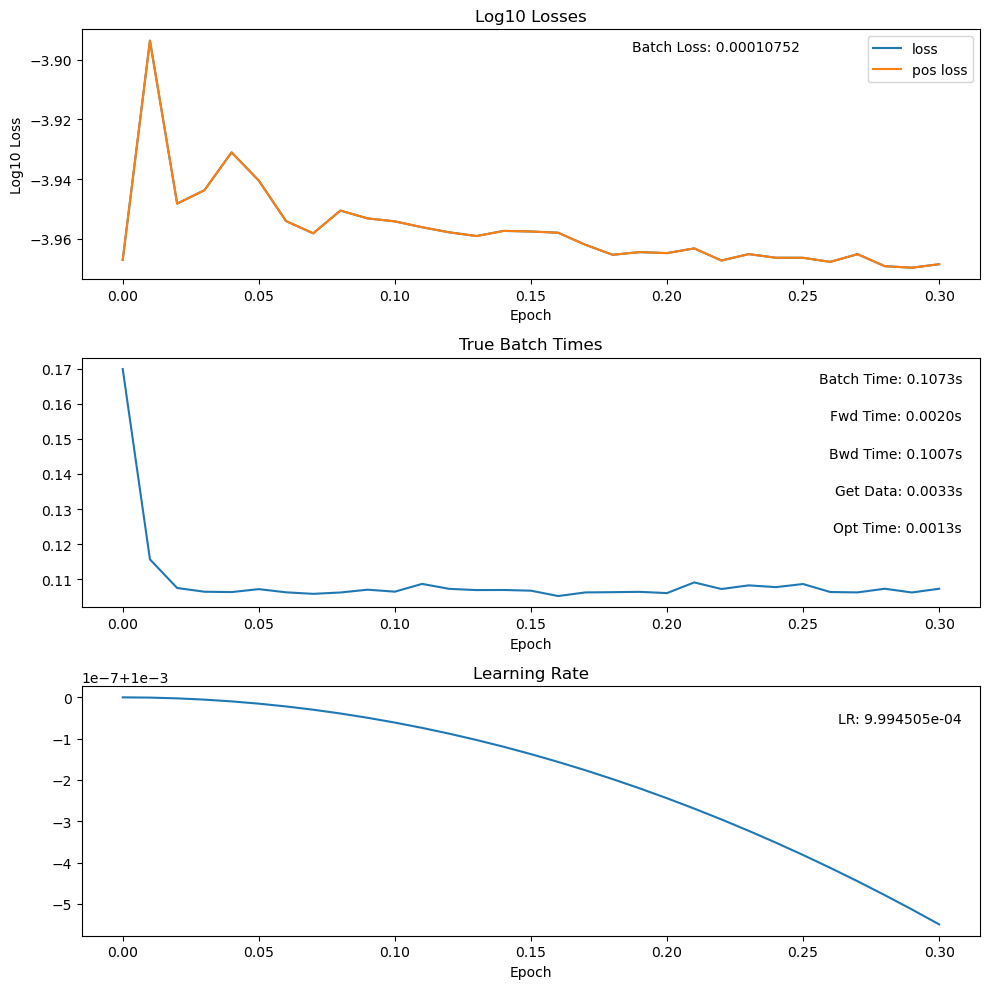

Epoch 0
Batch 3000
Loss: 0.00010752
  pos:       0.00010752
  normals:   0.00000000
  distort:   0.00000000
mean UDF: 0.00010752
learning rate: 0.00099945

Timing:
  batch time 0.1073s
  fwd 0.0020s | bwd 0.1007s | data 0.0033s | opt 0.0013s



KeyboardInterrupt: 

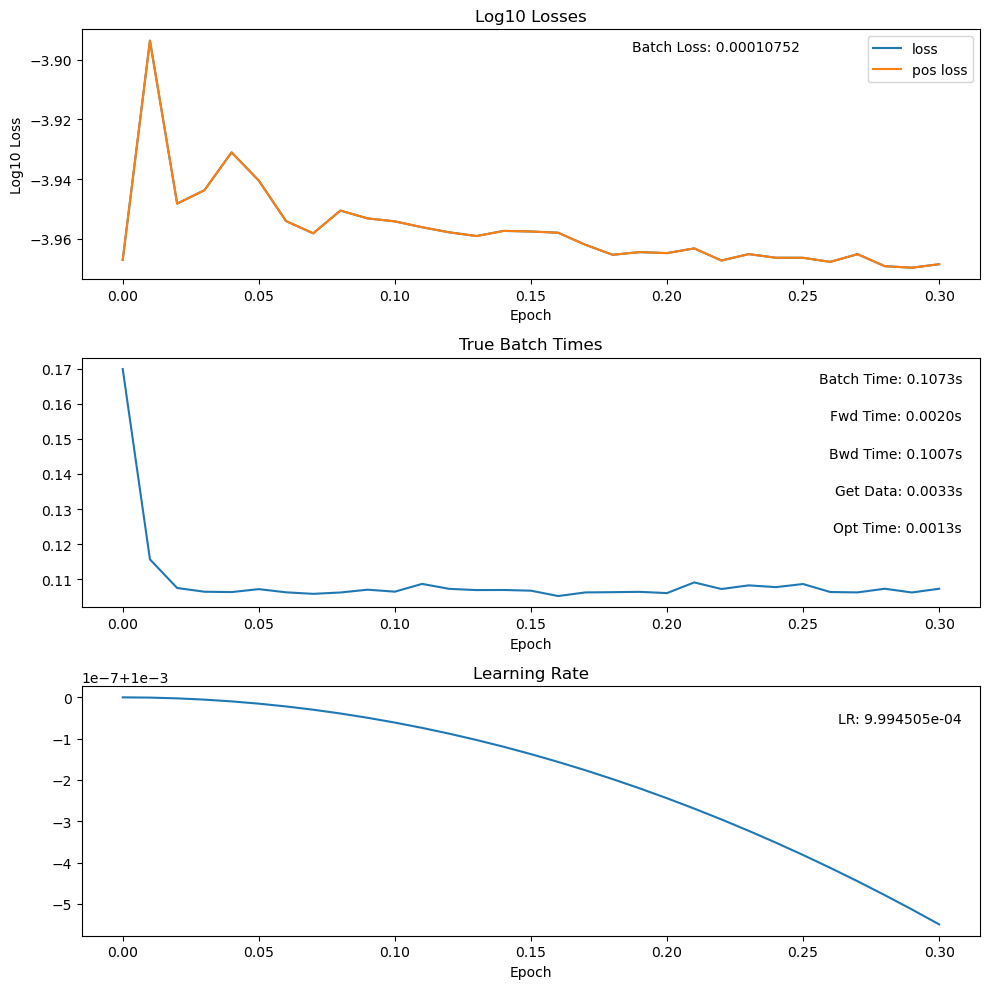

In [65]:
train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size , min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = normals_reg_coeff, distortion_reg_coeff = distortion_reg_coeff, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=area_weighting, save=save)

In [ ]:
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.0, distortion_reg_coeff = 0.00000, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=False)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.000001, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)#
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True, verify_gradient=False)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.00001, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)
#train_batch_loop(lr=None,  degree=None, batch_size=per_face_batch_size, min_loss=5e-5, max_epochs=max_epochs, normals_reg_coeff = 0.1, distortion_reg_coeff = 0.0, batch_plot_rate=10, plot=True, verify_gradient=False, area_weighting=True)

In [ ]:
save = True

checkpoint_dir = Path('models/surfaces')
checkpoint_filename = surface_config['coarse_patches_id'] + '.pth'   # e.g. "arm500.pth"

if save:
    bps.save_poly_coeffs(checkpoint_dir / checkpoint_filename)
    print(f"Saved polynomial coefficients to {checkpoint_dir / checkpoint_filename}")

################ visualise bns ##################

import visuals
import importlib
importlib.reload(visuals)
from visuals import *

bps_visualiser = BPS_visualiser(
    bps, mesh_res=6, just_onering=False, show_on_coarse=False, shape_name=shape_name,
    sdf_id=training_config['sdf_id'], sdf_model=DEEPSDF_MODEL, transition_width=transition_width,
)

settings = ['one-colour', 'unblended']

bps_visualiser.compute_quantities(settings=settings)
bps_visualiser.show_bps(settings=settings, save=save)   # output_dir omitted -> rendering/rendering_results/<shape_name>/


Saved polynomial coefficients to models/surfaces/double_torus500.pth
Precomputing blend weights etc, using pou_inv_exp blending.
Now deadling with poly basis
degree: 2


In [ ]:
'''
import visuals
importlib.reload(visuals)
from visuals import *





############# Translating a Single Coarse Vertex ############
bns.reset()


T = torch.zeros_like(bns.V)
T[0,:] = torch.tensor([-0.1, +0.1, 0.0 ])

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()

'''

"\nimport visuals\nimportlib.reload(visuals)\nfrom visuals import *\n\n\n\n\n\n############# Translating a Single Coarse Vertex ############\nbns.reset()\n\n\nT = torch.zeros_like(bns.V)\nT[0,:] = torch.tensor([-0.1, +0.1, 0.0 ])\n\nbns.V = bns.V + T\n\nbns.compute_fixed_rotations()\n\nbns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,\n                               show_on_coarse=False)\n\nbns_visualiser.compute_quantities()\nbns_visualiser.show_bns()\nbns.reset()\nbns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,\n                               show_on_coarse=False)\nbns_visualiser.compute_quantities()\nbns_visualiser.show_bns()\n\n"

In [ ]:

'''
############# Perturbing Vertices ############
bns.reset()


T = torch.zeros_like(bns.V)
T += 0.01*torch.randn(bns.V.shape)

bns.V = bns.V + T

bns.compute_fixed_rotations()

bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)

bns_visualiser.compute_quantities()
bns_visualiser.show_bns()
bns.reset()
bns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,
                               show_on_coarse=False)
bns_visualiser.compute_quantities()
bns_visualiser.show_bns()


'''

"\n############# Perturbing Vertices ############\nbns.reset()\n\n\nT = torch.zeros_like(bns.V)\nT += 0.01*torch.randn(bns.V.shape)\n\nbns.V = bns.V + T\n\nbns.compute_fixed_rotations()\n\nbns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,\n                               show_on_coarse=False)\n\nbns_visualiser.compute_quantities()\nbns_visualiser.show_bns()\nbns.reset()\nbns_visualiser = BNS_visualiser(bns, mesh_res=5, test_flag='poly', blend_type=blend_type, use_original_mesh=False,\n                               show_on_coarse=False)\nbns_visualiser.compute_quantities()\nbns_visualiser.show_bns()\n\n\n"

In [ ]:


'''
import visuals
importlib.reload(visuals)
from visuals import *

import implicit_reps
import importlib
importlib.reload(implicit_reps)
from implicit_reps import *

bps_visualiser = BPS_visualiser(bps, mesh_res=2, use_original_mesh=False,
                               show_on_coarse=False)

bps_visualiser.show_implicit_error_on_pcd(config_dict['shape_id'], num_samples=10000)
'''

"\nimport visuals\nimportlib.reload(visuals)\nfrom visuals import *\n\nimport implicit_reps\nimport importlib\nimportlib.reload(implicit_reps)\nfrom implicit_reps import *\n\nbps_visualiser = BPS_visualiser(bps, mesh_res=2, use_original_mesh=False,\n                               show_on_coarse=False)\n\nbps_visualiser.show_implicit_error_on_pcd(config_dict['shape_id'], num_samples=10000)\n"

In [ ]:

'''

for key in A.keys():
    print(key)
    #print( (A['equilateral_triangle_samples'] == B['equilateral_triangle_samples']).all() )
    print(A[key].requires_grad)


def check_view(t):
    return t._base is not None

for k, v in A.items():
    if torch.is_tensor(v):
        print(k, "is_view:", check_view(v))


def storage_ptr(t):
    return t.storage().data_ptr()

# gather grad-requiring tensors in your model
grad_tensors = []
for p in model.parameters():
    grad_tensors.append(p)

for k, v in A.items():
    if torch.is_tensor(v):
        for p in grad_tensors:
            if storage_ptr(v) == storage_ptr(p):
                print("ALIASES PARAM:", k)
'''

'\n\nfor key in A.keys():\n    print(key)\n    #print( (A[\'equilateral_triangle_samples\'] == B[\'equilateral_triangle_samples\']).all() )\n    print(A[key].requires_grad)\n\n\ndef check_view(t):\n    return t._base is not None\n\nfor k, v in A.items():\n    if torch.is_tensor(v):\n        print(k, "is_view:", check_view(v))\n\n\ndef storage_ptr(t):\n    return t.storage().data_ptr()\n\n# gather grad-requiring tensors in your model\ngrad_tensors = []\nfor p in model.parameters():\n    grad_tensors.append(p)\n\nfor k, v in A.items():\n    if torch.is_tensor(v):\n        for p in grad_tensors:\n            if storage_ptr(v) == storage_ptr(p):\n                print("ALIASES PARAM:", k)\n'

In [ ]:
A[]

SyntaxError: invalid syntax (913043970.py, line 1)